# PC. 06)

Desenvolver um modelo de classificação binária para detectar áreas com desmatamento ativo, usando imagens de satélite e variáveis ambientais como entrada. No entanto, o conjunto de dados apresenta alto desbalanceamento: apenas 5% das amostras representam desmatamento, enquanto os outros 95% correspondem a áreas preservadas. Simule ou carregue um conjunto de dados desbalanceado, com:

- Atributos numéricos ou derivados de imagens (podem ser sintéticos);
- Uma variável binária: 1 = desmatado, 0 = preservado.

Treine um modelo de classificação binária (MLP) e compare o desempenho usando:

- K-Fold comum (sem estratificação) e;
- Stratified K-Fold.

Ao final, discorra sobre as abordagens K-Fold tradicional e K-Fold estratificado. Em que situações a estratificação se torna fundamental? Considerando a importância da aplicação, quais as vantagens em utilizar a estratégia leave-one-out? A utilização dessa técnica é viável, considerando o tamanho do conjunto de dados? Fale sobre o custo computacional dessa estratégia de validação.

In [2]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 9.5 MB/s  0:00:00s eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 10.5 MB/s  0:00:03 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wtss-plugin 1.2.0 requires numpy!=1.24.0,<2,>=1.22, but you have numpy 2.1.3 which is incompatible.
wtss-plugin 1.2.0 requires scipy<=1.17.0, but you have scipy 1.17.1 which is incompatible.
pygam 0.12.0 requires scipy<1.17,>=1.11.1, but you have scipy 1.17.1 which is incompatible.


In [67]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [59]:
X, y = make_blobs(
    n_samples=10,
    centers=2,
    cluster_std=2,
    random_state=42
)

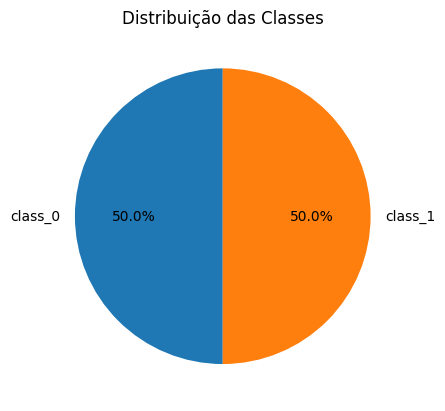

In [100]:
def plot_distribution(y):
    # Contar amostras por classe
    class_counts = pd.Series(y).value_counts().sort_index()
    
    # Labels (nomes das classes)
    labels = [ f'class_{n}' for n in list(set(y))]
    
    # Plotar gráfico de pizza
    plt.figure()
    plt.pie(class_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Distribuição das Classes')
    
    plt.show()

plot_distribution(y)

In [125]:
# Forçar desbalanço
def force_desbalance(X, y, props = {}):
    classes = np.unique(y)
    indices = {c: np.where(y == c)[0] for c in classes}
    
    n_total = len(y)
    new_indices = []    
    for c in classes:
        n_samples = int(props[c] * n_total)
        sampled = np.random.choice(indices[c], size=n_samples, replace=True)
        new_indices.extend(sampled)
        
    return X[new_indices], y[new_indices]

X_bal, y_bal = force_desbalance(X, y, props = {0: 0.90, 1: 0.20})
y_bal

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [123]:
class Kfold:

    def __init__(self, k=5, shuffle=True, random_state = 42):
        self.k = k
        self.shuffle = shuffle
        self.random_state = random_state

    def shuffle_data(self, X, y):
        indices = np.arange(X.shape[0])
        np.random.seed(self.random_state)
        np.random.shuffle(indices)
        return X[indices], y[indices]
    
    def get_folds(self, X, y):
        if self.shuffle:
          X, y = self.shuffle_data(X, y)
        fold_size = X.shape[0] // self.k
        
        folds = {}
        
        for i in range(self.k):
          start = i * fold_size
          end = start + fold_size
        
          X_val = X[start:end]
          y_val = y[start:end]
        
          X_train = np.concatenate([X[:start], X[end:]])
          y_train = np.concatenate([y[:start], y[end:]])
        
          folds[i] = {
              "X_train": X_train,
              "y_train": y_train,
              "X_val": X_val,
              "y_val": y_val
          }
        
        return folds

    def get_stratified_folds(self, X, y):
        if self.shuffle:
            X, y = self.shuffle_data(X, y)
    
        folds = {i: {"X_train": [], "y_train": [], "X_val": [], "y_val": []} for i in range(self.k)}

        for class_ in np.unique(y):
            class_idx = np.where(y == class_)[0]
            X_class = X[class_idx]
            y_class = y[class_idx]
            fold_size = X_class.shape[0] // self.k
    
            for i in range(self.k):
                start = i * fold_size
                end = start + fold_size
                
                X_val = X_class[start:end]
                y_val = y_class[start:end]

                print(fold_size, start, end)
    
                X_train = np.concatenate([X_class[:start], X_class[end:]])
                y_train = np.concatenate([y_class[:start], y_class[end:]])
    
                folds[i]["X_train"].append(X_train)
                folds[i]["y_train"].append(y_train)
                folds[i]["X_val"].append(X_val)
                folds[i]["y_val"].append(y_val)
    
        # juntar todas as classes em cada fold
        for i in range(self.k):
            folds[i]["X_train"] = np.concatenate(folds[i]["X_train"])
            folds[i]["y_train"] = np.concatenate(folds[i]["y_train"])
            folds[i]["X_val"] = np.concatenate(folds[i]["X_val"])
            folds[i]["y_val"] = np.concatenate(folds[i]["y_val"])

        return folds

    def plot_folds_distribution(self, folds, type_ = ""):
        k = len(folds)
    
        train_class0 = []
        train_class1 = []
        val_class0 = []
        val_class1 = []
    
        for i in range(k):
            y_train = folds[i]["y_train"]
            y_val = folds[i]["y_val"]
    
            train_counts = Counter(y_train)
            val_counts = Counter(y_val)
    
            total_train = len(y_train)
            total_val = len(y_val)
    
            train_class0.append(train_counts.get(0, 0) / total_train)
            train_class1.append(train_counts.get(1, 0) / total_train)
    
            val_class0.append(val_counts.get(0, 0) / total_val)
            val_class1.append(val_counts.get(1, 0) / total_val)
    
        x = np.arange(k)
    
        # ---- TRAIN ----
        plt.figure()
        bars_c0 = plt.bar(x, train_class0, label='Class 0')
        bars_c1 = plt.bar(x, train_class1, bottom=train_class0, label='Class 1')
    
        # labels
        for i in range(k):
            # class 0
            if train_class0[i] > 0:
                plt.text(
                    x[i],
                    train_class0[i] / 2,
                    f"{train_class0[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
            # class 1
            if train_class1[i] > 0:
                plt.text(
                    x[i],
                    train_class0[i] + train_class1[i] / 2,
                    f"{train_class1[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
    
        plt.ylim(0, 1)
        plt.xticks(x, [f"Fold {i}" for i in range(k)])
        plt.title(f"TRAIN - proporção por classe {type_}")
        plt.legend()
        plt.show()
    
        # ---- VALIDATION ----
        plt.figure()
        bars_c0 = plt.bar(x, val_class0, label='Class 0')
        bars_c1 = plt.bar(x, val_class1, bottom=val_class0, label='Class 1')
    
        # labels
        for i in range(k):
            if val_class0[i] > 0:
                plt.text(
                    x[i],
                    val_class0[i] / 2,
                    f"{val_class0[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
            if val_class1[i] > 0:
                plt.text(
                    x[i],
                    val_class0[i] + val_class1[i] / 2,
                    f"{val_class1[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
    
        plt.ylim(0, 1)
        plt.xticks(x, [f"Fold {i}" for i in range(k)])
        plt.title(f"VALIDATION - proporção por classe {type_}")
        plt.legend()
        plt.show()

kfold = Kfold()

normal_folds = kfold.get_folds(X, y)
stratified_folds = kfold.get_stratified_folds(X, y)

print(stratified_folds)

1 0 1
1 1 2
1 2 3
1 3 4
1 4 5
1 0 1
1 1 2
1 2 3
1 3 4
1 4 5
{0: {'X_train': array([[-3.43603301,  8.08282662],
       [-2.02527308,  5.18772564],
       [ 0.64922801, 10.54915559],
       [-2.97750437,  8.54601221],
       [ 1.19004317,  0.84859463],
       [ 7.57117637,  1.52161708],
       [ 2.6142166 ,  2.60166435],
       [ 4.77493525, -0.87632669]]), 'y_train': array([0, 0, 0, 0, 1, 1, 1, 1]), 'X_val': array([[-3.44814639, 10.09940622],
       [ 2.82383069, -0.85143772]]), 'y_val': array([0, 1])}, 1: {'X_train': array([[-3.44814639, 10.09940622],
       [-2.02527308,  5.18772564],
       [ 0.64922801, 10.54915559],
       [-2.97750437,  8.54601221],
       [ 2.82383069, -0.85143772],
       [ 7.57117637,  1.52161708],
       [ 2.6142166 ,  2.60166435],
       [ 4.77493525, -0.87632669]]), 'y_train': array([0, 0, 0, 0, 1, 1, 1, 1]), 'X_val': array([[-3.43603301,  8.08282662],
       [ 1.19004317,  0.84859463]]), 'y_val': array([0, 1])}, 2: {'X_train': array([[-3.44814639, 10.099406

In [124]:
normal_folds_bal = kfold.get_folds(X_bal, y_bal)
stratified_folds_bal = kfold.get_stratified_folds(X_bal, y_bal)

print(stratified_folds_bal)

# kfold.plot_folds_distribution(normal_folds_bal, "Tradicional Bal")
# kfold.plot_folds_distribution(stratified_folds_bal, "Estratificado Bal")

1 0 1
1 1 2
1 2 3
1 3 4
1 4 5
0 0 0
0 0 0
0 0 0
0 0 0
0 0 0
{0: {'X_train': array([[-2.02527308,  5.18772564],
       [-2.97750437,  8.54601221],
       [-2.02527308,  5.18772564],
       [-2.97750437,  8.54601221],
       [-2.02527308,  5.18772564],
       [-3.44814639, 10.09940622],
       [-2.02527308,  5.18772564],
       [-2.97750437,  8.54601221],
       [ 7.57117637,  1.52161708],
       [ 1.19004317,  0.84859463]]), 'y_train': array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1]), 'X_val': array([[-3.43603301,  8.08282662]]), 'y_val': array([0])}, 1: {'X_train': array([[-3.43603301,  8.08282662],
       [-2.97750437,  8.54601221],
       [-2.02527308,  5.18772564],
       [-2.97750437,  8.54601221],
       [-2.02527308,  5.18772564],
       [-3.44814639, 10.09940622],
       [-2.02527308,  5.18772564],
       [-2.97750437,  8.54601221],
       [ 7.57117637,  1.52161708],
       [ 1.19004317,  0.84859463]]), 'y_train': array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1]), 'X_val': array([[-2.02527308,  5.1877